In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/raw/food.csv")

In [3]:
df.head()

,Category,Description,Nutrient Data Bank Number,Data.Alpha Carotene,Data.Ash,Data.Beta Carotene,Data.Beta Cryptoxanthin,Data.Carbohydrate,Data.Cholesterol,Data.Choline,...,Data.Major Minerals.Potassium,Data.Major Minerals.Sodium,Data.Major Minerals.Zinc,Data.Vitamins.Vitamin A - IU,Data.Vitamins.Vitamin A - RAE,Data.Vitamins.Vitamin B12,Data.Vitamins.Vitamin B6,Data.Vitamins.Vitamin C,Data.Vitamins.Vitamin E,Data.Vitamins.Vitamin K
0,BUTTER,"BUTTER,WITH SALT",1001,0,2.11,158,0,0.06,215,19,...,24,576,0.09,2499,684,0.17,0.003,0.0,2.32,7.0
1,BUTTER,"BUTTER,WHIPPED,WITH SALT",1002,0,2.11,158,0,0.06,219,19,...,26,827,0.05,2499,684,0.13,0.003,0.0,2.32,7.0
2,BUTTER OIL,"BUTTER OIL,ANHYDROUS",1003,0,0.00,193,0,0.00,256,22,...,5,2,0.01,3069,840,0.01,0.001,0.0,2.80,8.6
3,CHEESE,"CHEESE,BLUE",1004,0,5.11,74,0,2.34,75,15,...,256,1395,2.66,763,198,1.22,0.166,0.0,0.25,2.4
4,CHEESE,"CHEESE,BRICK",1005,0,3.18,76,0,2.79,94,15,...,136,560,2.60,1080,292,1.26,0.065,0.0,0.26,2.5


In [4]:
df.shape

(7413, 48)

In [5]:
df.columns.tolist()

['Category',
 'Description',
 'Nutrient Data Bank Number',
 'Data.Alpha Carotene',
 'Data.Ash',
 'Data.Beta Carotene',
 'Data.Beta Cryptoxanthin',
 'Data.Carbohydrate',
 'Data.Cholesterol',
 'Data.Choline',
 'Data.Fiber',
 'Data.Kilocalories',
 'Data.Lutein and Zeaxanthin',
 'Data.Lycopene',
 'Data.Manganese',
 'Data.Niacin',
 'Data.Pantothenic Acid',
 'Data.Protein',
 'Data.Refuse Percentage',
 'Data.Retinol',
 'Data.Riboflavin',
 'Data.Selenium',
 'Data.Sugar Total',
 'Data.Thiamin',
 'Data.Water',
 'Data.Fat.Monosaturated Fat',
 'Data.Fat.Polysaturated Fat',
 'Data.Fat.Saturated Fat',
 'Data.Fat.Total Lipid',
 'Data.Household Weights.1st Household Weight',
 'Data.Household Weights.1st Household Weight Description',
 'Data.Household Weights.2nd Household Weight',
 'Data.Household Weights.2nd Household Weight Description',
 'Data.Major Minerals.Calcium',
 'Data.Major Minerals.Copper',
 'Data.Major Minerals.Iron',
 'Data.Major Minerals.Magnesium',
 'Data.Major Minerals.Phosphorus',
 'D

In [6]:
nutrition = df[[
    "Description",
    "Data.Kilocalories",
    "Data.Protein",
    "Data.Carbohydrate",
    "Data.Fat.Total Lipid"
]]

nutrition.head()

,Description,Data.Kilocalories,Data.Protein,Data.Carbohydrate,Data.Fat.Total Lipid
0,"BUTTER,WITH SALT",717,0.85,0.06,81.11
1,"BUTTER,WHIPPED,WITH SALT",717,0.85,0.06,81.11
2,"BUTTER OIL,ANHYDROUS",876,0.28,0.00,99.48
3,"CHEESE,BLUE",353,21.40,2.34,28.74
4,"CHEESE,BRICK",371,23.24,2.79,29.68


In [7]:
nutrition.sort_values(
    "Data.Protein",
    ascending=False
).head(20)

,Description,Data.Kilocalories,Data.Protein,Data.Carbohydrate,Data.Fat.Total Lipid
4797,"SOY PROT ISOLATE,K TYPE,CRUDE PROT BASIS",321,88.32,2.59,0.53
4700,"SOY PROT ISOLATE,PROT TECHNOLOGIES INTERNATION...",388,87.75,0.00,4.00
4701,"SOY PROT ISOLATE,PROT TECHNOLOGIES INTERNATION...",380,86.00,0.00,4.00
5858,"GELATINS,DRY PDR,UNSWTND",335,85.60,0.00,0.10
7057,"Seal, bearded (Oogruk), meat, dried (Alaska Na...",351,82.60,0.00,2.30
124,"EGG,WHITE,DRIED,PDR,GLUCOSE RED",376,82.40,4.47,0.04
158,"EGG,WHITE,DRIED",382,81.10,7.80,0.00
4796,"SOY PROT ISOLATE,K TYPE",326,80.69,10.22,0.53
4660,SOY PROTEIN ISOLATE,338,80.69,7.36,3.39
7138,"STEELHEAD TROUT,DRIED,FLESH (SHOSHONE BANNOCK)",382,77.27,0.00,8.06


In [ ]:
# Check for missing data
nutrition.isnull().sum()

Description             0
Data.Kilocalories       0
Data.Protein            0
Data.Carbohydrate       0
Data.Fat.Total Lipid    0
dtype: int64

In [ ]:
# Basic statistics
nutrition.describe()

,Data.Kilocalories,Data.Protein,Data.Carbohydrate,Data.Fat.Total Lipid
count,7413.000000,7413.000000,7413.000000,7413.000000
mean,219.655875,10.809883,21.785381,10.220476
std,171.668713,10.483772,27.123491,16.499285
min,0.000000,0.000000,0.000000,0.000000
25%,82.000000,2.130000,0.490000,0.740000
50%,181.000000,7.270000,9.290000,4.280000
75%,331.000000,18.580000,30.590000,12.950000
max,902.000000,88.320000,100.000000,100.000000


In [ ]:
# Create protein per calorie metric
nutrition["protein_per_calorie"] = (
    nutrition["Data.Protein"]
    / nutrition["Data.Kilocalories"]
)

In [ ]:
# Find best protein sources
nutrition.sort_values(
    "protein_per_calorie",
    ascending=False
)[[
    "Description",
    "Data.Kilocalories",
    "Data.Protein",
    "protein_per_calorie"
]].head(20)

,Description,Data.Kilocalories,Data.Protein,protein_per_calorie
4106,"CARBONATED BEV,LO CAL,OTHER THAN COLA OR PEPPE...",0,0.10,inf
4137,"COFFEE,BREWED,ESPRESSO,REST-PREP,DECAFFEINATED",0,0.10,inf
4136,"COFFEE,BREWED FROM GROUNDS,PREP W/ TAP H2O,DEC...",0,0.10,inf
4114,"CARB BEV,LO CAL,OTHR THN COLA OR PEPPER,W/ ASP...",0,0.10,inf
4797,"SOY PROT ISOLATE,K TYPE,CRUDE PROT BASIS",321,88.32,0.275140
5858,"GELATINS,DRY PDR,UNSWTND",335,85.60,0.255522
4796,"SOY PROT ISOLATE,K TYPE",326,80.69,0.247515
7058,"SEAL,BEARDED (OOGRUK),MEAT,RAW (ALASKA NATIVE)",110,26.70,0.242727
7069,"DUCK,SCOTER,WHITE-WINGED,MEAT (ALASKA NATIVE)",84,20.20,0.240476
7024,"Whale, beluga, meat, raw (Alaska Native)",111,26.50,0.238739


In [15]:
# Foods over 20g protein
nutrition[
    nutrition["Data.Protein"] >= 20
][[
    "Description",
    "Data.Kilocalories",
    "Data.Protein"
]].head(20)

,Description,Data.Kilocalories,Data.Protein
3,"CHEESE,BLUE",353,21.40
4,"CHEESE,BRICK",371,23.24
5,"CHEESE,BRIE",334,20.75
7,"CHEESE,CARAWAY",376,25.18
8,"CHEESE,CHEDDAR",403,24.90
9,"CHEESE,CHESHIRE",387,23.37
10,"CHEESE,COLBY",394,23.76
17,"CHEESE,EDAM",357,24.99
19,"CHEESE,FONTINA",389,25.60
21,"CHEESE,GOUDA",356,24.94


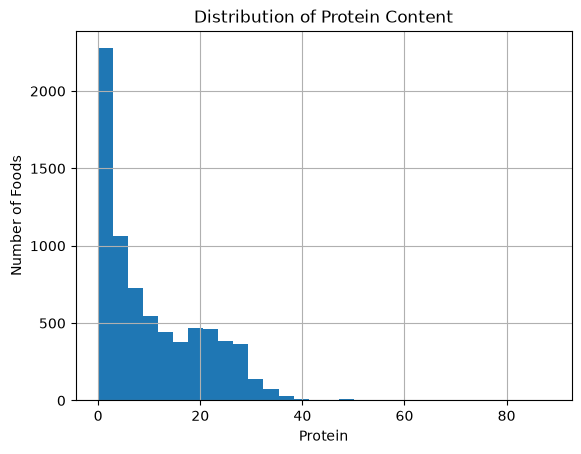

In [16]:
# Distribution of protein content
import matplotlib.pyplot as plt

nutrition["Data.Protein"].hist(
    bins=30
)

plt.title("Distribution of Protein Content")
plt.xlabel("Protein")
plt.ylabel("Number of Foods")
plt.show()

In [ ]:
# Most efficient protein amounts
high_protein_foods = nutrition[
    nutrition["Data.Protein"] >= 10
]

high_protein_foods.sort_values(
    "protein_per_calorie",
    ascending=False
)[[
    "Description",
    "Data.Kilocalories",
    "Data.Protein",
    "protein_per_calorie"
]].head(20)

,Description,Data.Kilocalories,Data.Protein,protein_per_calorie
4797,"SOY PROT ISOLATE,K TYPE,CRUDE PROT BASIS",321,88.32,0.275140
5858,"GELATINS,DRY PDR,UNSWTND",335,85.60,0.255522
4796,"SOY PROT ISOLATE,K TYPE",326,80.69,0.247515
7058,"SEAL,BEARDED (OOGRUK),MEAT,RAW (ALASKA NATIVE)",110,26.70,0.242727
7069,"DUCK,SCOTER,WHITE-WINGED,MEAT (ALASKA NATIVE)",84,20.20,0.240476
7024,"Whale, beluga, meat, raw (Alaska Native)",111,26.50,0.238739
4660,SOY PROTEIN ISOLATE,338,80.69,0.238728
7057,"Seal, bearded (Oogruk), meat, dried (Alaska Na...",351,82.60,0.235328
7070,"SEA CUCUMBER,YANE (ALASKA NATIVE)",56,13.00,0.232143
7133,"SEAL,BEARDED (OOGRUK),MEAT,PART DRIED (ALASKA ...",270,62.38,0.231037


In [19]:
# Protein per 100 calories
nutrition["protein_per_100_calories"] = (
    nutrition["Data.Protein"] 
    / nutrition["Data.Kilocalories"]
) * 100

nutrition[
    nutrition["Data.Kilocalories"] >= 50
].sort_values(
    "protein_per_100_calories",
    ascending=False
)[[
    "Description",
    "Data.Kilocalories",
    "Data.Protein",
    "protein_per_100_calories"
]].head(20)

,Description,Data.Kilocalories,Data.Protein,protein_per_100_calories
4797,"SOY PROT ISOLATE,K TYPE,CRUDE PROT BASIS",321,88.32,27.514019
5858,"GELATINS,DRY PDR,UNSWTND",335,85.60,25.552239
4796,"SOY PROT ISOLATE,K TYPE",326,80.69,24.751534
7058,"SEAL,BEARDED (OOGRUK),MEAT,RAW (ALASKA NATIVE)",110,26.70,24.272727
7069,"DUCK,SCOTER,WHITE-WINGED,MEAT (ALASKA NATIVE)",84,20.20,24.047619
7024,"Whale, beluga, meat, raw (Alaska Native)",111,26.50,23.873874
4660,SOY PROTEIN ISOLATE,338,80.69,23.872781
7057,"Seal, bearded (Oogruk), meat, dried (Alaska Na...",351,82.60,23.532764
7070,"SEA CUCUMBER,YANE (ALASKA NATIVE)",56,13.00,23.214286
7133,"SEAL,BEARDED (OOGRUK),MEAT,PART DRIED (ALASKA ...",270,62.38,23.103704


### Observation

The initial protein-per-calorie metric was dominated by very low-calorie beverages such as espresso and seltzer water.

To improve the analysis, foods with less than 10 grams of protein were excluded before ranking.